# Exploración y Preparación de Datos: Matrícula Asegurada SAE 2019
**Autor:** Cristian Riquelme | Analista de Datos

## 1. Configuración del Entorno
Importación de librerías y definición de las rutas a los archivos crudos (raw data).

In [25]:
import pandas as pd
import os

# Creación de directorio de salida si no existe
os.makedirs('../data/processed', exist_ok=True)

# Diccionario de rutas para mantener el código limpio y parametrizado
RUTAS = {
    'ficha': '../data/raw/SIGE_SAE_LOG_FICHA_CUPO_versionTest.csv',
    'log': '../data/raw/SIGE_SAE_LOG_CUPO_versionTest.csv',
    'anexo': '../data/raw/SIGE_SAE_LOG_ANEXO_SEDE_versionTest.csv',
    'admi': '../data/raw/ADMI_CURSO_versionTest.csv',
    'coles': '../data/raw/colesSAE_versionTest.csv',
    'oferta_test': '../data/raw/1_oferta_2019_test.csv',
    'fusiones': '../data/raw/fusionesAnexos_versionTest.csv',
    'codigos_nivel': '../data/raw/codigos_ens_grado_a_nivel_versionTest.csv',
    'matricula': '../data/raw/MATRICULA2018_versionTest.csv'
}

## 2. Ingesta de Datos y Manejo de Inconsistencias (El problema del separador)

**Hallazgo durante el EDA (Exploratory Data Analysis):** 
Al intentar realizar una lectura estándar de los archivos, se detectó una heterogeneidad en la estructura de los CSV provistos por el Ministerio. Mientras algunos archivos usan el estándar coma (`.csv`), otros utilizan punto y coma (`;`) y algunos, como el registro de logs, utilizan *pipes* (`|`). 

**Solución Implementada:**
Para no forzar la lectura manual archivo por archivo, se desarrolla una función de enrutamiento dinámico (`cargar_csv_seguro`) que itera sobre los posibles separadores y asegura la codificación `latin-1` (necesaria para caracteres del español como tildes y ñ).

In [ ]:
def cargar_csv_seguro(ruta, usecols=None, nrows=None):
    """
    Función para ingesta de datos.
    Intenta iterativamente distintos separadores para evitar fallos de lectura o
    la anidación errónea de todas las columnas en una sola resolviendo una complejidad inicial de carga.
    """
    separadores = [';', ',', '|']
    
    for sep in separadores:
        try:
            # Si usecols no coincide con el separador, Pandas lanzará ValueError
            df = pd.read_csv(ruta, sep=sep, encoding='latin-1', usecols=usecols, nrows=nrows)
            
            # Validación adicional: si no usamos usecols y todo quedó en 1 columna, el separador era incorrecto
            if usecols is None and len(df.columns) == 1:
                continue 
                
            return df
            
        except ValueError:
            continue # Intentar con el siguiente separador
            
    raise ValueError(f"Fallo crítico: No se pudieron parsear las columnas en {ruta}")

# Prueba con columnas de las tablas auxiliares para validar la función y explorar nombres.
print("Validación de lectura de columnas:")
print("1. Ficha Cupo:", cargar_csv_seguro(RUTAS['ficha'], nrows=1).columns.tolist()[:3], "...")
print("2. Log Cupo:", cargar_csv_seguro(RUTAS['log'], nrows=1).columns.tolist()[:3], "...")
print("3. Coles SAE:", cargar_csv_seguro(RUTAS['coles'], nrows=1).columns.tolist()[:3], "...")

Validación de lectura de columnas:
1. Ficha Cupo: ['rbd', 'tipo_alumnado', 'id_log_ficha_cupo'] ...
2. Log Cupo: ['RBD', 'ID_LOG_CUPO', 'FECHA_ULTIMA_ACTUALIZACION'] ...
3. Coles SAE: ['rbd', 'nombre', 'cod_reg'] ...


## 3. Desarrollo del Paso 1: Oferta 2019
Con la ingesta estabilizada, procedemos a cruzar las 5 tablas auxiliares para determinar los cursos que efectivamente tendrán continuidad en 2019, aplicando las reglas de negocio del protocolo (Vitrina activa, última fecha de actualización, validación de anexos y cruce con matriz oficial).

In [ ]:
# Carga de tablas
df_ficha = cargar_csv_seguro(RUTAS['ficha'])
df_log = cargar_csv_seguro(RUTAS['log'], usecols=['RBD', 'ID_LOG_CUPO', 'FECHA_ULTIMA_ACTUALIZACION', 'CARGADO_VITRINA'])
df_anexo = cargar_csv_seguro(RUTAS['anexo'])
df_admi = cargar_csv_seguro(RUTAS['admi'])
df_coles = cargar_csv_seguro(RUTAS['coles'])

# Estandarizar nombres, todo a minúscula para evitar errores
for df in [df_log, df_anexo, df_coles]:
    df.columns = df.columns.str.lower()

# Regla 1: Última actualización en vitrina
log_valido = df_log[df_log['cargado_vitrina'] == 1].copy()
log_valido['fecha_ultima_actualizacion'] = pd.to_datetime(log_valido['fecha_ultima_actualizacion'])
idx_max = log_valido.groupby('rbd')['fecha_ultima_actualizacion'].idxmax()
ids_validos = log_valido.loc[idx_max, 'id_log_cupo'].tolist()
oferta = df_ficha[df_ficha['id_log_cupo'].isin(ids_validos)].copy()

# Regla 2: Anexos
oferta = oferta.merge(df_anexo[['id_anexo', 'n_correlativo']], left_on='id_sede_anexo', right_on='id_anexo', how='left')
oferta['cod_sede'] = oferta['n_correlativo'].fillna(1).astype(int)

# Regla 3: Cupos válidos
oferta = oferta[oferta['total_cupos'] > 0]

# Regla 4 y 5: Emparejamiento de curso y lista oficial SAE
oferta['cod_genero'] = oferta['tipo_alumnado']
oferta['cod_jor'] = oferta['tipo_jornada']
oferta['cod_esp'] = oferta['cod_esp'].fillna(0).astype(int)
df_admi['cod_esp'] = df_admi['cod_esp'].fillna(0).astype(int)

oferta_final = oferta.merge(
    df_admi[['cod_curso', 'cod_nivel', 'cod_gra', 'cod_ens', 'cod_esp', 'cod_genero', 'cod_jor', 'cod_sede']],
    on=['cod_gra', 'cod_ens', 'cod_esp', 'cod_sede', 'cod_genero', 'cod_jor'],
    how='inner'
).merge(df_coles[['rbd']], on='rbd', how='inner')

oferta_final = oferta_final[['rbd', 'cod_nivel', 'cod_curso', 'total_cupos']]

ruta_oferta = '../data/processed/1_oferta_2019.csv'
oferta_final['total_cupos'] = oferta_final['total_cupos'].astype(int)
oferta_final.to_csv(ruta_oferta, index=False)
print(f"Paso 1 exportado con {len(oferta_final)} registros en: {ruta_oferta}")
print(f"\nPrimeras 5 filas del resultado:\n{oferta_final.head()}")

Paso 1 exportado con 18675 registros en: ../data/processed/1_oferta_2019.csv

Primeras 5 filas del resultado:
   rbd  cod_nivel     cod_curso  total_cupos
0   97          9  131000000133          120
1   97         10  231000000133          120
2   97         11  341041002133           40
3   97         11  341041005133           40
4   97         12  441041005133           35


## 4. Desarrollo del Paso 2: Cálculo de Matrícula Asegurada

**Desafío de Memoria RAM:** 
El archivo `MATRICULA2018` contiene más de 3.5 millones de registros (~400 MB). Cargar el dataframe completo en memoria ralentizaría el proceso.
**Estrategia:** Se utiliza el parámetro `usecols` dentro de nuestra función de ingesta para cargar estrictamente las 7 columnas necesarias para calcular la edad, el nivel y la continuidad, optimizando drásticamente los tiempos de ejecución. Decisión práctica al trabajar de modo local con vscode.

Se le agrega columnas de "región" y "tipo de dependencia", como complemento analítico, en pipeline final se excluirán entregando sólo las tres columnas solicitadas. 

In [28]:
# Carga de auxiliares
df_oferta_test = cargar_csv_seguro(RUTAS['oferta_test'])
df_fus = cargar_csv_seguro(RUTAS['fusiones'])
df_cod = cargar_csv_seguro(RUTAS['codigos_nivel'])

# Ingesta optimizada de Matrícula
cols_mat = ['rbd', 'fecha_incorporacion', 'fecha_retiro', 'cod_ens', 'cod_gra', 'sal_run', 'sal_fec_nac', 
            'cod_region', 'tipo_dependencia']
df_mat = cargar_csv_seguro(RUTAS['matricula'], usecols=cols_mat)
print(f"Registros iniciales ingeridos: {len(df_mat):,}")

# Filtros: Modalidad Regular y Alumnos Activos
ens_regular = [10, 110, 310, 410, 510, 610, 710, 810, 910]
df_mat = df_mat[df_mat['cod_ens'].isin(ens_regular)]
df_mat = df_mat[df_mat['fecha_retiro'].isna() | (df_mat['fecha_retiro'].astype(str).str.strip() == '')]

# Filtro de Edad (>= 4 años a marzo 2019)
df_mat['sal_fec_nac'] = pd.to_datetime(df_mat['sal_fec_nac'], errors='coerce', dayfirst=True)
df_mat['edad_2019'] = 2019 - df_mat['sal_fec_nac'].dt.year - (df_mat['sal_fec_nac'].dt.month > 3).astype(int)
df_mat = df_mat[df_mat['edad_2019'] >= 4]

# Determinar Nivel y filtrar
df_mat = df_mat.merge(df_cod, on=['cod_ens', 'cod_gra'], how='inner')
df_mat = df_mat[df_mat['cod_nivel'] >= -1]

# Desduplicación por run (Conservar último incorporado)
df_mat['fecha_incorporacion'] = pd.to_datetime(df_mat['fecha_incorporacion'], errors='coerce', dayfirst=True)
df_mat = df_mat.sort_values('fecha_incorporacion', ascending=False).drop_duplicates(subset=['sal_run'], keep='first')

# Proyección de Continuidad (Mapeo de RBD por fusiones y cruce con Oferta Test)
df_mat = df_mat.merge(df_fus[['rbd', 'rbd_principal']], on='rbd', how='left')
df_mat['rbd_2019'] = df_mat['rbd_principal'].fillna(df_mat['rbd']).astype(int)
df_mat['cod_nivel_2019'] = df_mat['cod_nivel'] + 1

oferta_pares = df_oferta_test[['rbd', 'cod_nivel']].drop_duplicates()
oferta_pares.rename(columns={'rbd': 'rbd_2019', 'cod_nivel': 'cod_nivel_2019'}, inplace=True)

df_final = df_mat.merge(oferta_pares, on=['rbd_2019', 'cod_nivel_2019'], how='inner')
df_final = df_final[['sal_run', 'rbd_2019', 'cod_nivel_2019', 'cod_region', 'tipo_dependencia']]

ruta_mat = '../data/processed/2_estudiantes_a_preinscribir.csv'
df_final.to_csv(ruta_mat, index=False)
print(f"Paso 2 completado. Estudiantes con continuidad asegurada: {len(df_final):,} guardados en: {ruta_mat}")
print(f"\nPrimeras 5 filas del resultado:\n{df_final.head()}")

Registros iniciales ingeridos: 3,558,149
Paso 2 completado. Estudiantes con continuidad asegurada: 924,248 guardados en: ../data/processed/2_estudiantes_a_preinscribir.csv

Primeras 5 filas del resultado:
    sal_run  rbd_2019  cod_nivel_2019  cod_region  tipo_dependencia
0  21387029     14289               6           5                 3
1  14107638     12368              11           9                 3
2  24822390      1996              10           5                 2
3   2927372     16410               8           7                 3
4   2172918      9304               3          13                 1


## 5. Análisis Exploratorio de Resultados (EDA de Continuidad)

1- Para comprender sociodemográficamente la reducción de registros (de 3.5 millones a ~924 mil), se presenta a continuación un desglose de cómo cada regla de negocio impactó el volumen final de matrícula asegurada. La mayor pérdida se concentra en estudiantes que egresan de niveles terminales donde su colegio no ofrece continuidad.

C:\Users\HP\AppData\Local\Temp\ipykernel_9768\2742830787.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Registros', y='Filtro', data=df_track, palette="viridis")


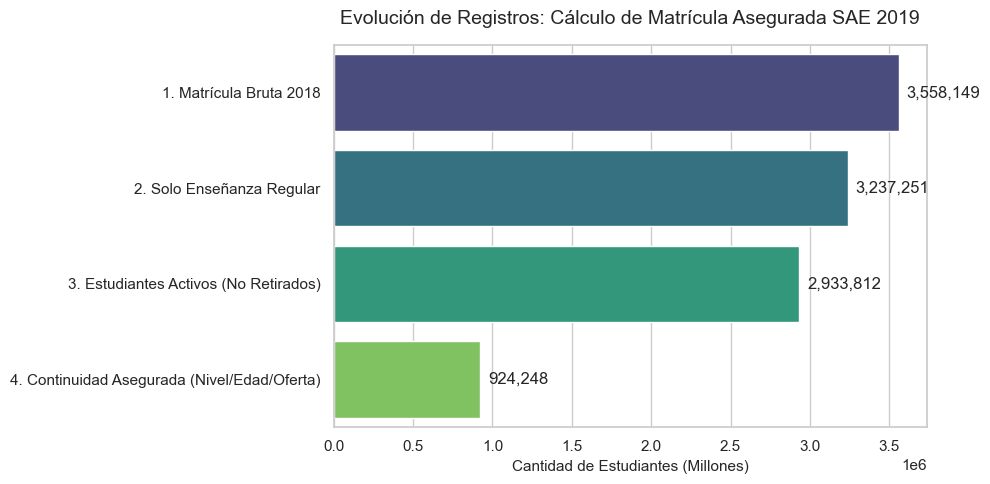

Distribución de Matrícula Asegurada por Nivel Escolar 2019 (Top 5):
Nivel Proyectado (2019)  Total Estudiantes
              2° Básico              83987
               2° Medio              83070
              3° Básico              82128
              4° Básico              81003
              5° Básico              78082


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tracker de registros
tracking = []
df_temp = cargar_csv_seguro(RUTAS['matricula'], usecols=cols_mat)
tracking.append({'Filtro': '1. Matrícula Bruta 2018', 'Registros': len(df_temp)})

# Filtro Modalidad
df_temp = df_temp[df_temp['cod_ens'].isin(ens_regular)]
tracking.append({'Filtro': '2. Solo Enseñanza Regular', 'Registros': len(df_temp)})

# Filtro Retirados
df_temp = df_temp[df_temp['fecha_retiro'].isna() | (df_temp['fecha_retiro'].astype(str).str.strip() == '')]
tracking.append({'Filtro': '3. Estudiantes Activos (No Retirados)', 'Registros': len(df_temp)})

tracking.append({'Filtro': '4. Continuidad Asegurada (Nivel/Edad/Oferta)', 'Registros': len(df_final)})
df_track = pd.DataFrame(tracking)

# 2. Visualización con Seaborn
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x='Registros', y='Filtro', data=df_track, palette="viridis")
plt.title('Evolución de Registros: Cálculo de Matrícula Asegurada SAE 2019', fontsize=14, pad=15)
plt.xlabel('Cantidad de Estudiantes (Millones)', fontsize=11)
plt.ylabel('')

# Añadir etiquetas de datos en las barras
for p in ax.patches:
    width = p.get_width()
    # f-string debe ir dentro de plt.text y todo bien cerrado
    plt.text(width + 50000, p.get_y() + p.get_height() / 2,
    f'{int(width):,}', ha='left', va='center')

plt.tight_layout()
plt.show()

# Diccionario de traducción de códigos a nombres legibles para rápida comprensión visual.
diccionario_niveles = {
    -1: 'Prekínder',
    0: 'Kínder',
    1: '1° Básico',
    2: '2° Básico',
    3: '3° Básico',
    4: '4° Básico',
    5: '5° Básico',
    6: '6° Básico',
    7: '7° Básico',
    8: '8° Básico',
    9: '1° Medio',
    10: '2° Medio',
    11: '3° Medio',
    12: '4° Medio'
}

# Generar la distribución y aplicar el mapeo
distribucion = df_final['cod_nivel_2019'].value_counts().reset_index()
distribucion.columns = ['Nivel Proyectado (2019)', 'Total Estudiantes']

# Se reemplazan los códigos por nombres usando el diccionario
distribucion['Nivel Proyectado (2019)'] = distribucion['Nivel Proyectado (2019)'].map(diccionario_niveles)

print("Distribución de Matrícula Asegurada por Nivel Escolar 2019 (Top 5):")
print(distribucion.head().to_string(index=False))

2- Se visualiza la distribución de Matrícula Asegurada por regiones para tener una perspectiva más completa de los resultados obtenidos con el procesameinto de las tablas. Además, se agrega el tido de dependencia del establecimiento educacional mediate gráfico de barras.


Concentración de Matrícula Asegurada por Región (Top 5):
       Región  Estudiantes
Metropolitana       333564
   Valparaíso        91982
       Biobío        86381
        Maule        60048
    Araucanía        58387

Distribución por Dependencia Administrativa:
        Dependencia  Total
Part. Subvencionado 534552
          Municipal 376526
      Adm. Delegada  13170


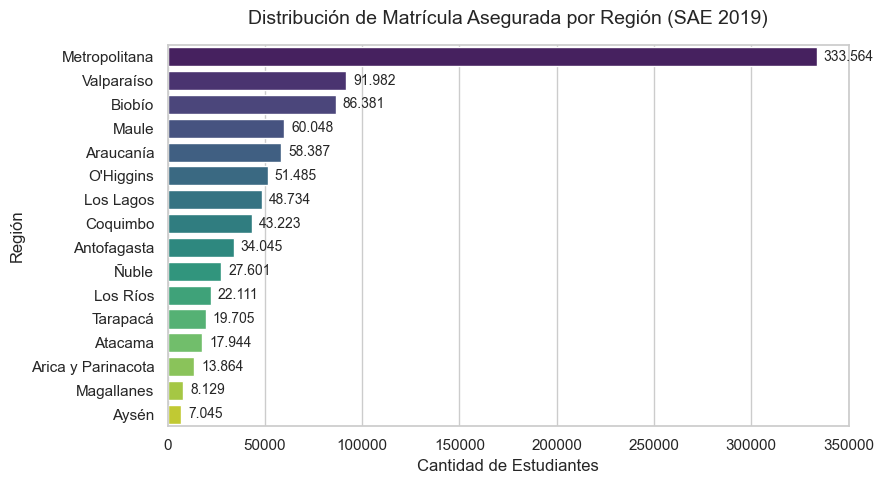

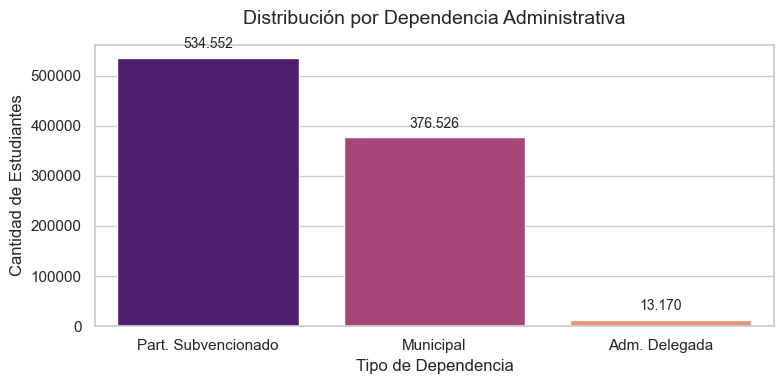

In [ ]:

# Diccionario de traducción de códigos a nombres legibles para rápida comprensión visual.
mapa_regiones = {
    1: "Tarapacá", 2: "Antofagasta", 3: "Atacama", 4: "Coquimbo", 5: "Valparaíso",
    6: "O'Higgins", 7: "Maule", 8: "Biobío", 9: "Araucanía", 10: "Los Lagos",
    11: "Aysén", 12: "Magallanes", 13: "Metropolitana", 14: "Los Ríos", 15: "Arica y Parinacota", 16: "Ñuble"
}

mapa_depe = {
    1: 'Municipal', 2: 'Municipal', 3: 'Part. Subvencionado', 4: 'Part. Pagado', 5: 'Adm. Delegada', 6: 'Slep'
}

# Regiones
dist_reg = df_final['cod_region'].value_counts().reset_index()
dist_reg.columns = ['Región', 'Estudiantes']
dist_reg['Región'] = dist_reg['Región'].map(mapa_regiones)

print("\nConcentración de Matrícula Asegurada por Región (Top 5):")
print(dist_reg.head().to_string(index=False))

# Dependencias
dist_depe = df_final['tipo_dependencia'].map(mapa_depe).value_counts().reset_index()
dist_depe.columns = ['Dependencia', 'Total']

print("\nDistribución por Dependencia Administrativa:")
print(dist_depe.to_string(index=False))

sns.set_theme(style="whitegrid")

# Gráfico Regional
plt.figure(figsize=(9, 5))
dist_reg_sorted = dist_reg.sort_values('Estudiantes', ascending=False)

ax1 = sns.barplot(x='Estudiantes', y='Región', data=dist_reg_sorted, palette='viridis', hue='Región', legend=False)
plt.title('Distribución de Matrícula Asegurada por Región (SAE 2019)', fontsize=14, pad=15)
plt.xlabel('Cantidad de Estudiantes', fontsize=12)
plt.ylabel('Región', fontsize=12)

# Etiquetas numéricas
for p in ax1.patches:
    ax1.annotate(f"{int(p.get_width()):,}".replace(',', '.'), 
            (p.get_width(), p.get_y() + p.get_height() / 2.),  ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

# Gráfico de Dependencia
plt.figure(figsize=(8, 4))

ax2 = sns.barplot(x='Dependencia', y='Total', data=dist_depe, palette='magma', hue='Dependencia', legend=False)
plt.title('Distribución por Dependencia Administrativa', fontsize=14, pad=15)
plt.xlabel('Tipo de Dependencia', fontsize=12)
plt.ylabel('Cantidad de Estudiantes', fontsize=12)

# Etiquetas numéricas
for p in ax2.patches:
    ax2.annotate(f"{int(p.get_height()):,}".replace(',', '.'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

---

## 6. Conclusión Ejecutiva

El procesamiento de los datos del Sistema de Admisión Escolar (SAE) 2019 revela el impacto territorial y estructural de la política de continuidad de matrícula.

*   **Eficiencia del Filtro:** De un universo inicial de más de 3.5 millones de registros históricos, el algoritmo asegura la continuidad exacta de **924.248 estudiantes**, validando el cumplimiento estricto de las reglas de negocio (modalidad regular, alumnos activos, edad reglamentaria y oferta validada en vitrina).
*   **Concentración Territorial:** La **Región Metropolitana** concentra la mayor parte de la matrícula asegurada (~333.564 estudiantes), seguida por Valparaíso y Biobío, lo cual es coherente con la distribución demográfica nacional.
*   **Estructura del Sistema Educativo:** El cruce con los datos de dependencia administrativa confirma que la oferta de continuidad se sostiene mayoritariamente sobre el sector **Particular Subvencionado** (~534.552 estudiantes), seguido por el sector **Municipal** (~376.526 estudiantes agrupados). Como es correcto dentro del marco regulatorio del SAE, el sector Particular Pagado no registra continuidad en este proceso.

El notebook desarrollado demuestra técnica en el manejo de memoria y limpieza de datos irregulares, entregando archivos de salida listos para la integración en los sistemas centrales del Ministerio. Con esto, el código ha sido empaquetado en un script de producción "pipeline_sae.py", contenido en la raíz de la entrega, que ejecuta todo el proceso automatizado ya que no se encontraron errores y los archivos fueron creados y guardados correctamente en entorno local.